# Olist E-Commerce — Exploratory Data Analysis

**Goal:** understand how the business behaves before building the dashboard, and test one claim with statistics.

**Data:** the `mart` star schema in PostgreSQL (built by the SQL files in `sql/`).
**Period:** January 2017 to August 2018.

Questions answered here:
1. How did revenue and orders grow?
2. Is there a weekly or daily pattern?
3. Which categories and states matter most?
4. How long does delivery take, and how happy are customers?
5. Does late delivery hurt review scores? (hypothesis test)
6. Do customers come back?

In [1]:
import sys
sys.path.append("..")  # so the notebook can import from src/

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

from src.db import get_engine

engine = get_engine()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4.5)

## 1. Growth: revenue and orders by month

In [2]:
monthly = pd.read_sql("SELECT * FROM mart.kpi_monthly ORDER BY month_start", engine, parse_dates=["month_start"])
monthly["revenue"] = monthly["revenue"].astype(float)
monthly[["year_month", "orders", "revenue", "aov", "revenue_mom_growth_pct"]]

,year_month,orders,revenue,aov,revenue_mom_growth_pct
0,2017-01,800,127482.37,169.98,NaN
1,2017-02,1780,271239.32,164.09,112.77
2,2017-03,2682,414330.95,162.74,52.75
3,2017-04,2404,390812.40,169.70,-5.68
4,2017-05,3700,566851.40,159.86,45.04
5,2017-06,3245,490050.37,156.32,-13.55
6,2017-07,4026,566299.08,146.25,15.56
7,2017-08,4331,645832.36,154.03,14.04
8,2017-09,4285,701077.49,168.93,8.55
9,2017-10,4631,751117.01,167.73,7.14


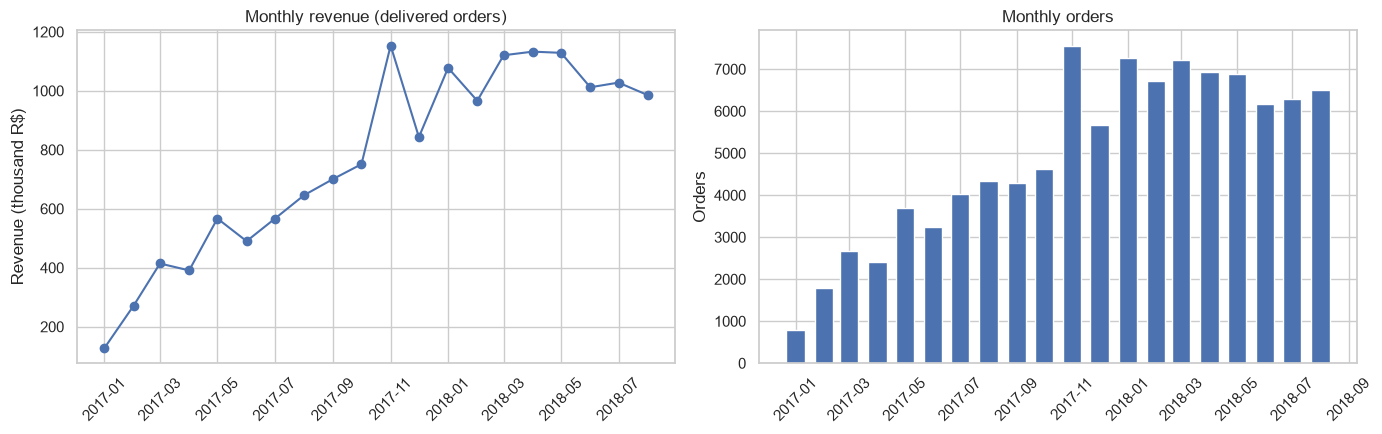

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(monthly["month_start"], monthly["revenue"] / 1000, marker="o")
axes[0].set_title("Monthly revenue (delivered orders)")
axes[0].set_ylabel("Revenue (thousand R$)")

axes[1].bar(monthly["month_start"], monthly["orders"], width=20)
axes[1].set_title("Monthly orders")
axes[1].set_ylabel("Orders")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [4]:
first_half_2017 = monthly[monthly["year_month"].between("2017-01", "2017-06")]["revenue"].mean()
first_half_2018 = monthly[monthly["year_month"].between("2018-01", "2018-06")]["revenue"].mean()
print(f"Average monthly revenue Jan-Jun 2017: {first_half_2017:,.0f}")
print(f"Average monthly revenue Jan-Jun 2018: {first_half_2018:,.0f}")
print(f"Growth: {first_half_2018 / first_half_2017:.1f}x")
print("Best month:", monthly.loc[monthly["revenue"].idxmax(), "year_month"])

Average monthly revenue Jan-Jun 2017: 376,794
Average monthly revenue Jan-Jun 2018: 1,073,048
Growth: 2.8x
Best month: 2017-11


## 2. Seasonality: day of week and hour of day

In [5]:
orders = pd.read_sql(
    '''
    SELECT f.order_id, f.order_purchase_timestamp, f.is_delivered, f.is_late,
           f.delivery_days, f.review_score, f.order_revenue,
           d.day_of_week, d.day_name, c.customer_state
    FROM mart.fact_orders AS f
    JOIN mart.dim_date AS d ON d.date_key = f.order_date
    JOIN mart.dim_customer AS c ON c.customer_id = f.customer_id
    WHERE f.in_analysis_window
    ''',
    engine,
    parse_dates=["order_purchase_timestamp"],
)
orders["delivery_days"] = orders["delivery_days"].astype(float)
orders["order_revenue"] = orders["order_revenue"].astype(float)
orders["hour"] = orders["order_purchase_timestamp"].dt.hour
len(orders)

99092

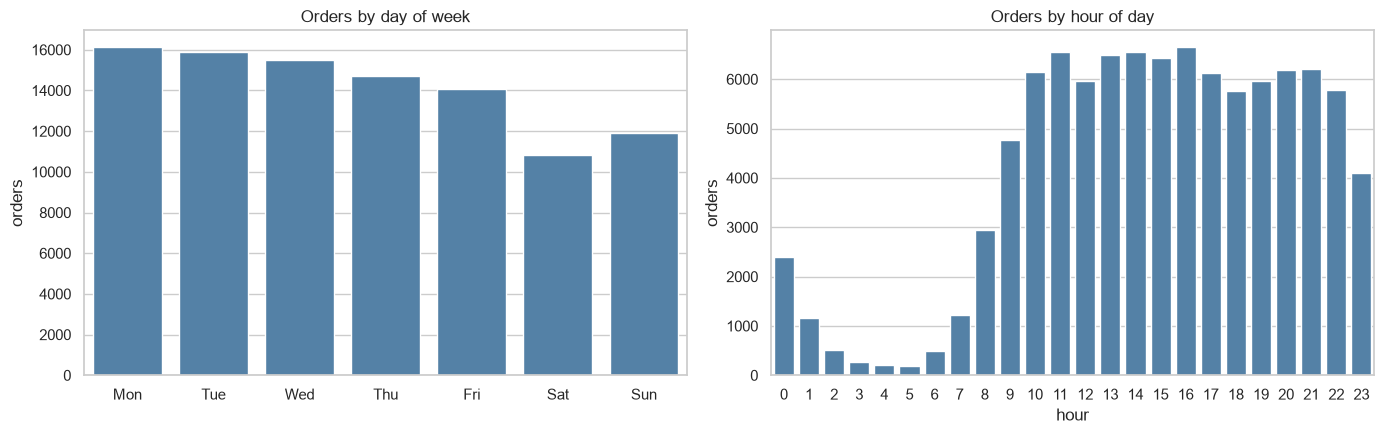

Weekend days get 25% fewer orders than weekdays.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_day = orders.groupby(["day_of_week", "day_name"]).size().reset_index(name="orders")
sns.barplot(data=by_day, x="day_name", y="orders", ax=axes[0], color="steelblue")
axes[0].set_title("Orders by day of week")
axes[0].set_xlabel("")

by_hour = orders.groupby("hour").size().reset_index(name="orders")
sns.barplot(data=by_hour, x="hour", y="orders", ax=axes[1], color="steelblue")
axes[1].set_title("Orders by hour of day")

plt.tight_layout()
plt.show()

weekday_avg = by_day[by_day["day_of_week"] <= 5]["orders"].mean()
weekend_avg = by_day[by_day["day_of_week"] >= 6]["orders"].mean()
print(f"Weekend days get {100 * (1 - weekend_avg / weekday_avg):.0f}% fewer orders than weekdays.")

## 3. What sells, and where

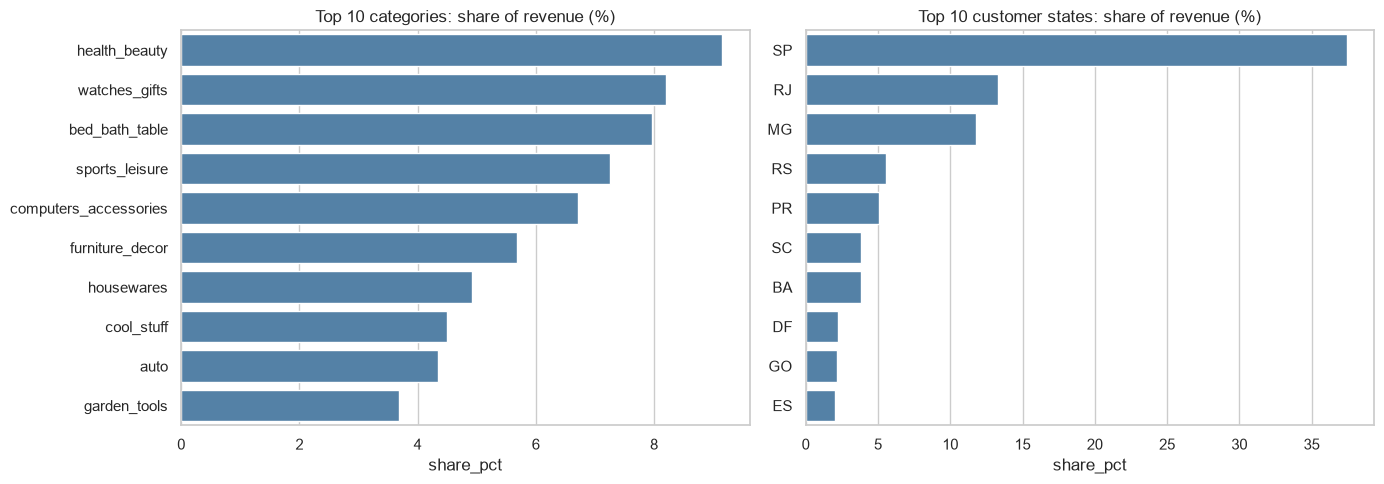

Number of categories: 74
Top 7 categories together: 50% of revenue
Top 3 states together: 63% of revenue


In [7]:
category = pd.read_sql(
    "SELECT category, SUM(revenue) AS revenue, SUM(orders) AS orders FROM mart.kpi_monthly_by_category GROUP BY category ORDER BY revenue DESC",
    engine,
)
category["revenue"] = category["revenue"].astype(float)
category["share_pct"] = 100 * category["revenue"] / category["revenue"].sum()
category["cumulative_pct"] = category["share_pct"].cumsum()

state = pd.read_sql(
    "SELECT customer_state, SUM(revenue) AS revenue, SUM(orders) AS orders FROM mart.kpi_monthly_by_state GROUP BY customer_state ORDER BY revenue DESC",
    engine,
)
state["revenue"] = state["revenue"].astype(float)
state["share_pct"] = 100 * state["revenue"] / state["revenue"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=category.head(10), y="category", x="share_pct", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 categories: share of revenue (%)")
axes[0].set_ylabel("")
sns.barplot(data=state.head(10), y="customer_state", x="share_pct", ax=axes[1], color="steelblue")
axes[1].set_title("Top 10 customer states: share of revenue (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print(f"Number of categories: {len(category)}")
print(f"Top 7 categories together: {category['cumulative_pct'].iloc[6]:.0f}% of revenue")
print(f"Top 3 states together: {state['share_pct'].head(3).sum():.0f}% of revenue")

## 4. Delivery time and customer satisfaction

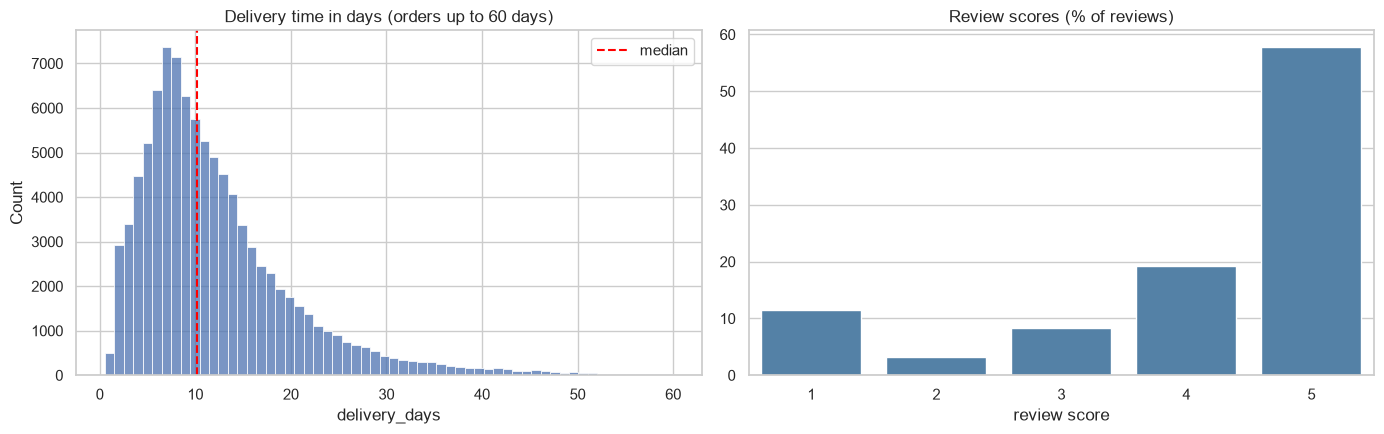

count    96203.0
mean        12.5
std          9.5
min          0.5
25%          6.8
50%         10.2
75%         15.7
max        209.6
Name: delivery_days, dtype: float64

Late deliveries: 6.8% of delivered orders


In [8]:
delivered = orders[orders["is_delivered"] & orders["delivery_days"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(delivered[delivered["delivery_days"] <= 60]["delivery_days"], bins=60, ax=axes[0])
axes[0].axvline(delivered["delivery_days"].median(), color="red", linestyle="--", label="median")
axes[0].set_title("Delivery time in days (orders up to 60 days)")
axes[0].legend()

score_share = orders["review_score"].value_counts(normalize=True).sort_index() * 100
sns.barplot(x=score_share.index.astype(int), y=score_share.values, ax=axes[1], color="steelblue")
axes[1].set_title("Review scores (% of reviews)")
axes[1].set_xlabel("review score")
plt.tight_layout()
plt.show()

print(delivered["delivery_days"].describe().round(1))
print(f"\nLate deliveries: {100 * delivered['is_late'].mean():.1f}% of delivered orders")

In [9]:
# Delivery speed and satisfaction by state (states with at least 500 delivered orders)
by_state = (
    delivered.groupby("customer_state")
    .agg(orders=("order_id", "count"), avg_delivery_days=("delivery_days", "mean"),
         late_pct=("is_late", lambda s: 100 * s.mean()), avg_review=("review_score", "mean"))
    .query("orders >= 500")
    .sort_values("avg_delivery_days")
    .round(2)
)
pd.concat([by_state.head(3), by_state.tail(3)])

,orders,avg_delivery_days,late_pct,avg_review
customer_state,,,,
SP,40399,8.74,4.50,4.25
PR,4903,11.97,4.06,4.24
MG,11319,11.98,4.59,4.19
CE,1273,21.24,13.83,3.94
MA,713,21.54,17.53,3.83
PA,942,23.76,11.25,3.91


## 5. Does late delivery hurt review scores?

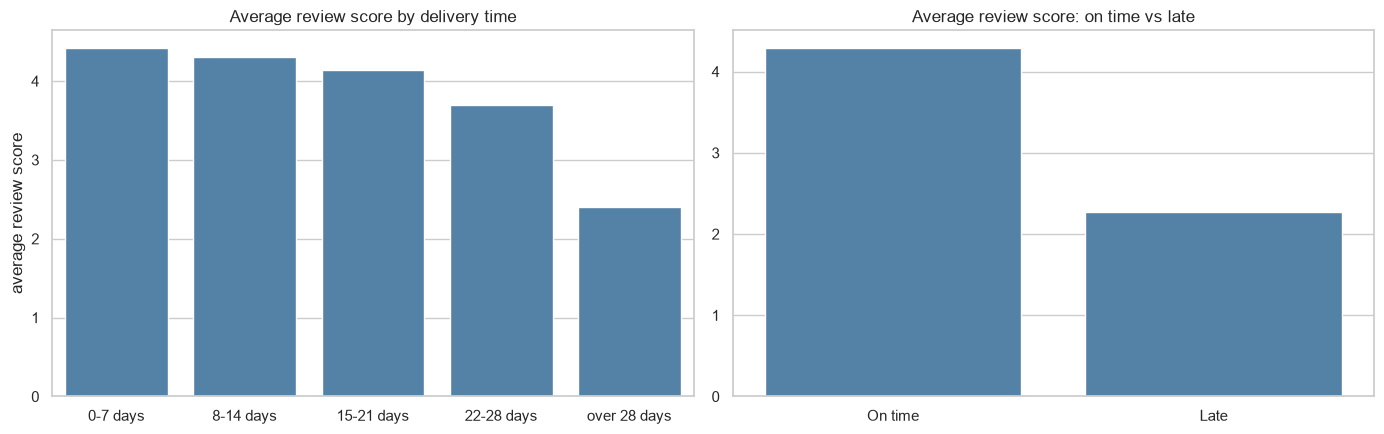

,mean,count
delivery_bucket,,
0-7 days,4.42,25977
8-14 days,4.31,39874
15-21 days,4.14,17507
22-28 days,3.69,6778
over 28 days,2.40,5424


In [10]:
reviewed = delivered[delivered["review_score"].notna()].copy()
reviewed["delivery_bucket"] = pd.cut(
    reviewed["delivery_days"], bins=[0, 7, 14, 21, 28, 400],
    labels=["0-7 days", "8-14 days", "15-21 days", "22-28 days", "over 28 days"],
)
bucket = reviewed.groupby("delivery_bucket", observed=True)["review_score"].agg(["mean", "count"]).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=bucket.index, y=bucket["mean"], ax=axes[0], color="steelblue")
axes[0].set_title("Average review score by delivery time")
axes[0].set_ylabel("average review score")
axes[0].set_xlabel("")

late_vs_ontime = reviewed.groupby("is_late")["review_score"].mean()
sns.barplot(x=["On time", "Late"], y=[late_vs_ontime[False], late_vs_ontime[True]], ax=axes[1], color="steelblue")
axes[1].set_title("Average review score: on time vs late")
plt.tight_layout()
plt.show()
bucket

### Hypothesis test

- **H0 (null hypothesis):** late orders and on-time orders get the same review scores.
- **H1 (alternative):** late orders get lower review scores than on-time orders.

**Test used: Mann-Whitney U.** Review scores are whole numbers from 1 to 5 and are heavily skewed towards 5, so they are not normally distributed. A t-test assumes roughly normal data; Mann-Whitney only compares the ranks of the two groups, so it fits this kind of data.

**Significance level:** 0.05.

In [11]:
late_scores = reviewed[reviewed["is_late"] == True]["review_score"]
on_time_scores = reviewed[reviewed["is_late"] == False]["review_score"]

u_statistic, p_value = stats.mannwhitneyu(late_scores, on_time_scores, alternative="less")

# Effect size: chance that a random on-time order has a higher score than a random late order
# (ties count as half).
effect = 1 - u_statistic / (len(late_scores) * len(on_time_scores))

print(f"Late orders    : n = {len(late_scores):,}   mean = {late_scores.mean():.2f}   median = {late_scores.median():.0f}")
print(f"On-time orders : n = {len(on_time_scores):,}   mean = {on_time_scores.mean():.2f}   median = {on_time_scores.median():.0f}")
print(f"U statistic = {u_statistic:,.0f}")
print("p-value < 0.001" if p_value < 0.001 else f"p-value = {p_value:.4f}")
print(f"Chance a random on-time order scores higher than a random late order: {100 * effect:.0f}%")
print(f"Share of 1-2 star reviews: late = {100 * (late_scores <= 2).mean():.1f}%, on time = {100 * (on_time_scores <= 2).mean():.1f}%")

Late orders    : n = 6,378   mean = 2.27   median = 1
On-time orders : n = 89,182   mean = 4.29   median = 5
U statistic = 102,901,002
p-value < 0.001
Chance a random on-time order scores higher than a random late order: 82%
Share of 1-2 star reviews: late = 62.4%, on time = 9.2%


**Result:** the p-value is far below 0.05, so H0 is rejected. Late orders get clearly lower review scores, and the difference is large, not just statistically detectable: the average falls from about 4.3 to about 2.3 stars.

## 6. Do customers come back?

 customers  repeat_customers  repeat_customer_pct
     93104              2789                  3.0


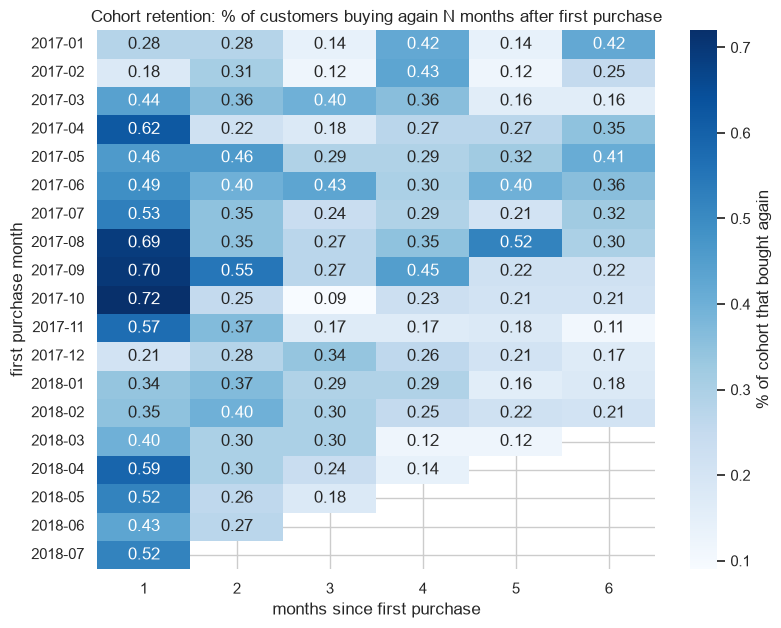

In [12]:
repeat = pd.read_sql("SELECT * FROM mart.repeat_customer_summary", engine)
print(repeat.to_string(index=False))

cohort = pd.read_sql("SELECT * FROM mart.cohort_retention WHERE months_since_first BETWEEN 1 AND 6", engine, parse_dates=["cohort_month"])
cohort["cohort"] = cohort["cohort_month"].dt.strftime("%Y-%m")
heatmap = cohort.pivot(index="cohort", columns="months_since_first", values="retention_pct").astype(float)

plt.figure(figsize=(9, 7))
sns.heatmap(heatmap, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "% of cohort that bought again"})
plt.title("Cohort retention: % of customers buying again N months after first purchase")
plt.xlabel("months since first purchase")
plt.ylabel("first purchase month")
plt.show()

## Findings

1. **The business grew about 2.8x in a year.** Average monthly revenue rose from about R$ 377k (Jan-Jun 2017) to about R$ 1.07M (Jan-Jun 2018). November 2017 was the best month, driven by Black Friday; growth flattened through 2018.

2. **Orders follow a clear weekly pattern.** Monday to Wednesday are the busiest days and weekends get about 25% fewer orders than weekdays. Any day-level comparison has to allow for this.

3. **Revenue is concentrated.** The top 7 of 74 categories bring in half of all revenue, and three states (SP, RJ, MG) account for about 63%. São Paulo alone is about 37%.

4. **Delivery is slow and uneven across the country.** The median delivery takes about 10 days. São Paulo customers wait under 9 days on average, while northern states such as Pará and Maranhão wait over 21 days and have late-delivery rates above 11%.

5. **Late delivery is the clearest driver of bad reviews.** On-time orders average 4.29 stars; late orders average 2.27. 62% of late orders get 1 or 2 stars, compared with 9% of on-time orders (Mann-Whitney U, p < 0.001).

6. **Almost nobody buys twice.** Only 3% of customers placed more than one order, and monthly cohort retention stays below 1%. Growth here comes from new customers, not repeat ones.